#### 把之前的 90 维长条，恢复成 [30天, 3个特征] 的立体结构。

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import akshare as ak
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. 念定身咒
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

# ==========================================
# 数据获取与预处理
# ==========================================
df_real = ak.stock_zh_index_daily(symbol="sh000300")
df_real = df_real[['date', 'open', 'high', 'low', 'close', 'volume']]

# 增加特征：MA5
df_real['MA5'] = df_real['close'].rolling(window=5).mean()
# 增加特征：MACD (12, 26, 9)
ema12 = df_real['close'].ewm(span=12, adjust=False).mean()
ema26 = df_real['close'].ewm(span=26, adjust=False).mean()
df_real['macd_line'] = ema12 - ema26
df_real['signal_line'] = df_real['macd_line'].ewm(span=9, adjust=False).mean()
# 增加特征：RSI (14日)
delta = df_real['close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_real['rsi_14'] = 100 - (100 / (1 + rs))

# 增加目标：当日收益率 (今天收盘 / 昨天收盘 - 1)
df_real['return'] = df_real['close'].pct_change()#pct_change()百分比变化

# 删掉前 4 天 MA5 的空值，以及第 1 天 return 的空值
df_real = df_real.dropna().reset_index(drop=True)

# 归一化（只归一化特征，不归一化收益率 return，因为收益率本身就是很小的百分比）
features = ['close', 'volume', 'MA5', 'macd_line', 'signal_line', 'rsi_14']
scaler = MinMaxScaler()
df_real[features] = scaler.fit_transform(df_real[features])

# ==========================================
# 3D 数据集定义
# ==========================================
class LSTMStockDataset(Dataset):
    def __init__(self, df, feature_list, window_size=30):
        # 动态提取特征列
        self.x_data = df[feature_list].values
        self.y_data = df['return'].values
        self.window_size = window_size

    def __len__(self):
        return len(self.x_data) - self.window_size

    def __getitem__(self, idx):
        x = self.x_data[idx : idx + self.window_size]
        x = torch.tensor(x, dtype=torch.float32)
        y = self.y_data[idx + self.window_size] 
        y = torch.tensor([y], dtype=torch.float32)
        return x, y

# 实例化时传入 features 列表
lstm_ds = LSTMStockDataset(df_real, feature_list=features, window_size=30)

lstm_loader = DataLoader(lstm_ds, batch_size=8, shuffle=False)

# 测试一下新引擎吐出的数据形状
batch_x, batch_y = next(iter(lstm_loader))
print(f"batch_x 的形状: {batch_x.shape}") 
print(f"batch_y 的形状: {batch_y.shape}")

batch_x 的形状: torch.Size([8, 30, 6])
batch_y 的形状: torch.Size([8, 1])


In [5]:
# ==========================================
# LSTM 模型定义
# ==========================================
class LSTMQuantModel(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, num_layers=1):
        #input_dim=6 告诉模型每天会进来几个数字（比如 close, volume, MA5, macd_line, signal_line, rsi_14，加起来正好是 6 个）。
        #hidden_dim=64 64 意味着它会用 64 个神经元来提取和记住特征
        #隐藏层维度的确定：从 64 或 128 起步做 Baseline（基准测试）。
#如果发现模型训练时 Loss 降不下来，说明容量不够，把它翻倍到 128 或 256；
#如果发现模型在训练集上表现极好，但在测试集上过拟合，把它降到 32，或者加入 Dropout 层来限制它的记忆。
        super().__init__() #把 PyTorch 底层复杂的神经网络机制（比如求导功能、参数更新功能）全部激活
        self.hidden_dim = hidden_dim
        
        # 核心部件：LSTM 层
        # batch_first=True 表示我们输入的数据第一维是 batch_size
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        
        # 预测部件：把 LSTM 的记忆浓缩成一个收益率预测值
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x 的形状是 [batch, 30, 3]
        
        # LSTM 会输出两个东西：out 是所有 30 天的记忆，(hn, cn) 是最后的隐状态
        out, (hn, cn) = self.lstm(x)
        # out 的形状变成了 [batch, 30, hidden_dim]
        
        # 我们只关心最后一天（第30天）读完后，大脑里的最终记忆
        # [:, -1, :] 的意思是：所有的 batch，最后一天 (-1)，所有的隐层特征
        last_out = out[:, -1, :] 
        
        # 通过全连接层输出预测
        return self.fc(last_out)

# 实例化新模型
lstm_model = LSTMQuantModel(input_dim=6, hidden_dim=64)

# 验证模型能不能跑通
pred = lstm_model(batch_x)
print(f"模型预测出的形状: {pred.shape}")

模型预测出的形状: torch.Size([8, 1])


In [6]:
# ==========================================
# LSTM 训练引擎
# ==========================================
# 1. 设置裁判和教练
criterion = nn.MSELoss()#Mean Squared Error（均方误差）
# 注意：这里把模型换成了 lstm_model
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

epochs = 15 # 稍微多跑几轮看看效果

print("启动 LSTM 收益率预测训练...")
for epoch in range(epochs):
    lstm_model.train() # 告诉模型进入训练模式
    epoch_loss = 0.0
    
    for batch_x, batch_y in lstm_loader:
        optimizer.zero_grad()       # 清空上一步的残余梯度
        
        pred = lstm_model(batch_x)  # 预测收益率
        loss = criterion(pred, batch_y) # 裁判对答案
        
        loss.backward()             # 反向传播找错误原因
        optimizer.step()            # 更新记忆权重
        
        epoch_loss += loss.item()
    
    # 计算每个 epoch 的平均 Loss
    avg_loss = epoch_loss / len(lstm_loader)
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.6f}")

print("训练完成！")

启动 LSTM 收益率预测训练...
Epoch 01 | Loss: 0.000312
Epoch 02 | Loss: 0.000262
Epoch 03 | Loss: 0.000261
Epoch 04 | Loss: 0.000260
Epoch 05 | Loss: 0.000259
Epoch 06 | Loss: 0.000259
Epoch 07 | Loss: 0.000258
Epoch 08 | Loss: 0.000257
Epoch 09 | Loss: 0.000256
Epoch 10 | Loss: 0.000256
Epoch 11 | Loss: 0.000255
Epoch 12 | Loss: 0.000254
Epoch 13 | Loss: 0.000254
Epoch 14 | Loss: 0.000252
Epoch 15 | Loss: 0.000251
训练完成！


In [8]:
lstm_model.eval()
all_preds = []
with torch.no_grad():
    for xb, yb in lstm_loader:
        pred = lstm_model(xb)
        all_preds.extend(pred.squeeze().tolist())

# 将预测值存入 df（注意补齐 window_size 造成的偏移）
df_real = df_real.iloc[30:].copy() 
df_real['pred'] = all_preds
df_real.to_csv('enhanced_performance_results.csv', index=False)

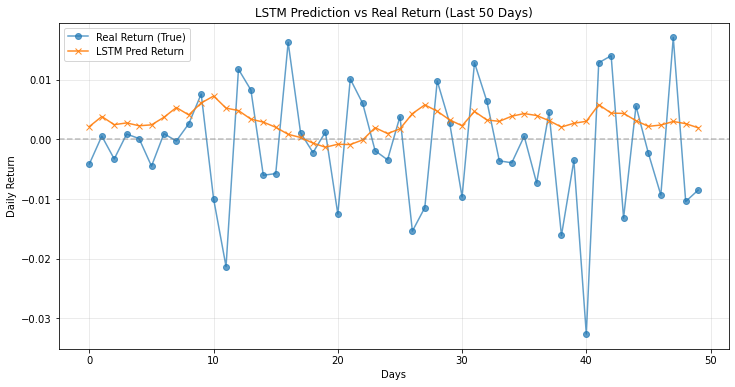

In [ ]:
import matplotlib.pyplot as plt

# 1. 切换到评估模式（关掉可能影响预测的内部机制）
lstm_model.eval()

# 2. 收集所有的预测值和真实值
all_preds = []
all_reals = []

with torch.no_grad(): # 关掉梯度追踪，省内存跑得快
    for batch_x, batch_y in lstm_loader:
        pred = lstm_model(batch_x)
        # 把每一批次的结果拉平并塞进列表里
        all_preds.extend(pred.numpy().flatten())
        all_reals.extend(batch_y.numpy().flatten())

# 3. 截取最后 50 天的数据画图
show_days = 50
plt.figure(figsize=(12, 6))

# 画出真实收益率（蓝色圆点）和预测收益率（橙色叉叉）
plt.plot(all_reals[-show_days:], label='Real Return (True)', marker='o', alpha=0.7)
plt.plot(all_preds[-show_days:], label='LSTM Pred Return', marker='x', alpha=0.9)

# 加上一条水平基准线（代表收益率为 0，不涨不跌）
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.title(f"LSTM Prediction vs Real Return (Last {show_days} Days)")
plt.xlabel("Days")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import scipy.stats as stats

# 计算 IC (Pearson 相关系数：衡量线性预测的准确度)
ic, p_value_ic = stats.pearsonr(all_preds, all_reals)

# 计算 Rank IC (Spearman 秩相关系数：衡量方向和排序的准确度)
rank_ic, p_value_rank = stats.spearmanr(all_preds, all_reals)

print("模型预测能力评估 (IC & Rank IC) ")
print("-" * 40)
print(f" 模型 IC      : {ic:.4f}")
print(f" 模型 Rank IC : {rank_ic:.4f}")
print("-" * 40)

# 简单解读一下
if rank_ic > 0.05:
    print(" 评价：极好！模型具有非常强的预测能力。")
elif rank_ic > 0.02:
    print(" 评价：不错！模型已经摸到了一些有效规律，具备实战微调价值。")
elif rank_ic > 0:
    print(" 评价：偏弱。比瞎猜好一点点，需要增加更多的特征（如MACD/RSI）或调整参数。")
else:
    print(" 评价：反向指标？预测方向和真实方向经常相反。")

模型预测能力评估 (IC & Rank IC) 
----------------------------------------
 模型 IC      : 0.0358
 模型 Rank IC : 0.0118
----------------------------------------
 评价：偏弱。比瞎猜好一点点，需要增加更多的特征（如MACD/RSI）或调整参数。


[main adf4603] feat: 閲嶆瀯04鏂囦欢寮曞叆LSTM澶ц剳锛岃窇閫� Rank IC 璇勪及浣撶郴
 1 file changed, 47 insertions(+), 7 deletions(-)


To https://github.com/xxxxzzh/DeepLearning-Quant-Framework.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/xxxxzzh/DeepLearning-Quant-Framework.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


To https://github.com/xxxxzzh/DeepLearning-Quant-Framework.git
 + 0771fd3...adf4603 main -> main (forced update)
